# MNIST Case Align Nearest-Neighbour Evaluation

Focused notebook for high/low Case Align nearest-neighbour inspection.

This notebook uses cosine distance consistently:
- **Problem space**: cosine distance over flattened MNIST images for nearest-neighbour retrieval.
- **Solution space**: cosine distance over flattened explanation maps, matching the saved Case Align evaluation config.

It loads existing artifacts and score files by default. Set `RUN_EVALUATION = True` only if you want to refresh the Case Align scores with the parameters printed below.

In [1]:
from pathlib import Path
import json
import sys
import subprocess

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

cwd = Path.cwd().resolve()
if (cwd / 'mnist_explain_predictions.py').exists():
    SRC_ROOT = cwd
elif (cwd / 'src' / 'mnist_explain_predictions.py').exists():
    SRC_ROOT = cwd / 'src'
elif (cwd.parent / 'mnist_explain_predictions.py').exists():
    SRC_ROOT = cwd.parent
else:
    raise RuntimeError('Could not locate src directory containing mnist_explain_predictions.py')

EXPLANATION_ARTIFACT = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_explanations.pt'
PREDICTIONS_CSV = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_predictions.csv'
SCORES_CSV = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_explanation_scores.csv'
SUMMARY_CSV = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_method_summary.csv'
EVALUATION_CONFIG_JSON = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_evaluation_config.json'
EXPLANATION_CONFIG_JSON = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_explanation_config.json'
MODEL_PATH = SRC_ROOT / 'models' / 'mnist' / 'mnist_best_model.pt'
DATA_DIR = SRC_ROOT / 'data'
OUTPUT_DIR = SRC_ROOT / 'results' / 'mnist_visualizations' / 'nearest_neighbour_case_align'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'SRC_ROOT: {SRC_ROOT}')
print(f'Artifacts exist: explanations={EXPLANATION_ARTIFACT.exists()}, scores={SCORES_CSV.exists()}, summary={SUMMARY_CSV.exists()}')
print(f'Output dir: {OUTPUT_DIR}')

SRC_ROOT: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src
Artifacts exist: explanations=True, scores=True, summary=True
Output dir: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align


In [9]:
# Case Align/evaluation parameters.
# The evaluator uses the same --sim-metric for both problem and solution contexts.
RUN_EVALUATION = False

CASE_ALIGN_PARAMS = {
    'k': 5,
    'sim_metric': 'cosine',
    'problem_metric': 'cosine',
    'solution_metric': 'cosine',
    'perturb_radius': 0.1,
    'n_perturb_samples': 10,
    'retrieval_batch_size': 256,
}

EXPERIMENT_PARAMS = {
    'reference_method': 'dl',
    'selection_strategy': 'same class with largest Case Align spread; choose max/min S+ within that class',
    'display_k_neighbours': 5,
    'neighbour_problem_distance': 'cosine over flattened raw MNIST images',
    'reported_solution_distance': 'cosine over flattened attribution maps',
    'overlay_alpha': 0.58,
    'normalisation_percentile': 99.0,
    'output_dir': str(OUTPUT_DIR),
}

print('Case Align parameters used by this notebook:')
display(pd.Series(CASE_ALIGN_PARAMS, name='value').to_frame())
print('Nearest-neighbour experiment parameters:')
display(pd.Series(EXPERIMENT_PARAMS, name='value').to_frame())

if EVALUATION_CONFIG_JSON.exists():
    saved_eval_config = json.loads(EVALUATION_CONFIG_JSON.read_text())
    print('Saved evaluator config found:')
    display(pd.Series(saved_eval_config, name='value').to_frame())
    if saved_eval_config.get('sim_metric') != 'cosine':
        print('WARNING: saved scores were not generated with cosine. Set RUN_EVALUATION=True to refresh them.')
else:
    saved_eval_config = None
    print('No saved evaluator config found. Set RUN_EVALUATION=True to generate one.')

if EXPLANATION_CONFIG_JSON.exists():
    saved_explanation_config = json.loads(EXPLANATION_CONFIG_JSON.read_text())
    print('Saved explanation config found:')
    display(pd.Series(saved_explanation_config, name='value').to_frame())

Case Align parameters used by this notebook:


,value
k,5
sim_metric,cosine
problem_metric,cosine
solution_metric,cosine
perturb_radius,0.1
n_perturb_samples,10
retrieval_batch_size,256


Nearest-neighbour experiment parameters:


,value
reference_method,dl
selection_strategy,same class with largest Case Align spread; cho...
display_k_neighbours,5
neighbour_problem_distance,cosine over flattened raw MNIST images
reported_solution_distance,cosine over flattened attribution maps
overlay_alpha,0.58
normalisation_percentile,99.0
output_dir,/Users/craigpirie/Documents/PhD/AGREE_ICCBR/ag...


Saved evaluator config found:


,value
artifact_path,/Users/craigpirie/Documents/PhD/AGREE_ICCBR/ag...
model_path,/Users/craigpirie/Documents/PhD/AGREE_ICCBR/ag...
data_dir,/Users/craigpirie/Documents/PhD/AGREE_ICCBR/ag...
methods,"[ig, dl, lrp]"
k,25
sim_metric,cosine
perturb_radius,0.1
n_perturb_samples,10
retrieval_pool_size,10000
retrieval_batch_size,256


Saved explanation config found:


,value
methods,"[ig, dl, lrp]"
baseline_type,zero
n_samples,2000
model_path,/Users/craigpirie/Documents/PhD/AGREE_ICCBR/ag...
artifact_path,/Users/craigpirie/Documents/PhD/AGREE_ICCBR/ag...
manifest_path,/Users/craigpirie/Documents/PhD/AGREE_ICCBR/ag...


In [10]:
if RUN_EVALUATION:
    eval_cmd = [
        sys.executable,
        str(SRC_ROOT / 'mnist_evaluate_explanations.py'),
        '--artifact-path', str(EXPLANATION_ARTIFACT),
        '--model-path', str(MODEL_PATH),
        '--data-dir', str(DATA_DIR),
        '--output-dir', str(SRC_ROOT / 'explanations' / 'mnist'),
        '--k', str(CASE_ALIGN_PARAMS['k']),
        '--sim-metric', CASE_ALIGN_PARAMS['sim_metric'],
        '--perturb-radius', str(CASE_ALIGN_PARAMS['perturb_radius']),
        '--n-perturb-samples', str(CASE_ALIGN_PARAMS['n_perturb_samples']),
        '--retrieval-batch-size', str(CASE_ALIGN_PARAMS['retrieval_batch_size']),
    ]
    print('Running evaluator:')
    print(' '.join(eval_cmd))
    subprocess.run(eval_cmd, check=True)
else:
    print('RUN_EVALUATION=False: using existing score/config artifacts.')

RUN_EVALUATION=False: using existing score/config artifacts.


In [11]:
artifact = torch.load(EXPLANATION_ARTIFACT, map_location='cpu')
pred_df = pd.read_csv(PREDICTIONS_CSV)
scores_df = pd.read_csv(SCORES_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

images = artifact['images'].numpy()  # [N,1,28,28]
labels = artifact['labels'].numpy().astype(int)
pred_labels = artifact['pred_labels'].numpy().astype(int)
confidences = artifact['confidences'].numpy().astype(float)
methods = [m.lower() for m in artifact['methods']]
attributions = {m: artifact['attributions'][m].numpy() for m in methods}

if 'case_align_has_like_neighbour' in scores_df.columns:
    scores_df['case_align_has_like_neighbour'] = scores_df['case_align_has_like_neighbour'].astype(bool)
    unsupported_mask = ~scores_df['case_align_has_like_neighbour']
    scores_df.loc[unsupported_mask, ['case_align_S_plus', 'case_align_R_bounded']] = np.nan
else:
    unsupported_mask = pd.Series(False, index=scores_df.index)

print(f'N images: {len(images)}')
print(f'Methods: {methods}')
print(f'Case Align unavailable rows: {int(unsupported_mask.sum())}')
display(summary_df.sort_values('method').reset_index(drop=True))

N images: 2000
Methods: ['ig', 'dl', 'lrp']
Case Align unavailable rows: 0


,method,n_samples,n_case_align_valid,mean_case_align_S_plus,mean_case_align_R_bounded,mean_captum_sensitivity,std_captum_sensitivity,pearson_case_align_vs_sensitivity,pearson_p_value,spearman_case_align_vs_sensitivity,spearman_p_value
0,dl,2000,2000,0.458812,0.458812,1.194515,0.279080,0.056193,0.011955,-0.013491,0.546507
1,ig,2000,2000,0.541253,0.541253,0.876022,0.269895,-0.015568,0.486523,-0.064965,0.003654
2,lrp,2000,2000,0.457866,0.457866,0.378077,0.086450,0.054499,0.014787,-0.002470,0.912098


In [12]:
METHOD_LABEL = {'ig': 'Integrated Gradients', 'dl': 'DeepLift', 'lrp': 'LRP'}

def normalise_attr(attr_map: np.ndarray, percentile: float = 99.0) -> np.ndarray:
    arr = np.asarray(attr_map, dtype=float).squeeze()
    scale = np.percentile(np.abs(arr), percentile) + 1e-8
    arr = np.clip(arr / scale, -1.0, 1.0)
    return arr

def safe_normalise_rows(matrix: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(norms, eps)

def cosine_distance_matrix_to_query(matrix: np.ndarray, query_vec: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    matrix_norm = safe_normalise_rows(matrix, eps=eps)
    query_norm = safe_normalise_rows(np.asarray(query_vec, dtype=float)[None, :], eps=eps)[0]
    similarity = matrix_norm @ query_norm
    return np.clip(1.0 - 0.5 * (similarity + 1.0), 0.0, 1.0)

def cosine_distance(vec_a: np.ndarray, vec_b: np.ndarray, eps: float = 1e-12) -> float:
    a = np.asarray(vec_a, dtype=float).reshape(1, -1)
    return float(cosine_distance_matrix_to_query(a, np.asarray(vec_b, dtype=float).ravel(), eps=eps)[0])

def score_row(method: str, sample_position: int) -> pd.Series:
    row = scores_df[(scores_df['method'] == method) & (scores_df['sample_position'] == sample_position)]
    if row.empty:
        raise ValueError(f'No score row for method={method}, sample_position={sample_position}')
    return row.iloc[0]

def select_same_class_case_align_pair(reference_method: str, k_neighbours: int = 5):
    ref = scores_df[
        (scores_df['method'] == reference_method) &
        scores_df['case_align_S_plus'].notna()
    ][['sample_position', 'true_label', 'case_align_S_plus', 'captum_sensitivity']].copy()

    if ref.empty:
        raise ValueError(f"No valid Case Align rows for method '{reference_method}'.")

    class_counts = pd.Series(labels).value_counts().astype(int)
    feasible_classes = set(class_counts[class_counts >= (k_neighbours + 1)].index.astype(int))
    feasible_ref = ref[ref['true_label'].isin(feasible_classes)].copy()

    if feasible_ref.empty:
        raise ValueError(
            f"No classes have at least {k_neighbours + 1} samples. "
            f"Current counts: {dict(sorted(class_counts.to_dict().items()))}."
        )

    class_spreads = []
    for label, group in feasible_ref.groupby('true_label'):
        if len(group) < 2:
            continue
        class_spreads.append({
            'true_label': int(label),
            'n_valid': int(len(group)),
            'case_align_min': float(group['case_align_S_plus'].min()),
            'case_align_max': float(group['case_align_S_plus'].max()),
            'case_align_spread': float(group['case_align_S_plus'].max() - group['case_align_S_plus'].min()),
        })

    spread_df = pd.DataFrame(class_spreads).sort_values(
        ['case_align_spread', 'n_valid'], ascending=[False, False]
    ).reset_index(drop=True)
    selected_label = int(spread_df.iloc[0]['true_label'])
    selected_ref = feasible_ref[feasible_ref['true_label'] == selected_label].copy()

    high_pos = int(selected_ref.sort_values('case_align_S_plus', ascending=False).iloc[0]['sample_position'])
    low_pos = int(selected_ref.sort_values('case_align_S_plus', ascending=True).iloc[0]['sample_position'])

    return {
        'high': high_pos,
        'low': low_pos,
        'label': selected_label,
        'summary': spread_df,
        'class_counts': class_counts,
    }

flat_images = images[:, 0].reshape(len(images), -1).astype(float)
flat_attributions = {m: attributions[m][:, 0].reshape(len(images), -1).astype(float) for m in methods}

def closest_same_class_neighbours_cosine(anchor_pos: int, method: str, k: int = 5) -> pd.DataFrame:
    anchor_label = int(labels[anchor_pos])
    candidates = np.where(labels == anchor_label)[0]
    candidates = candidates[candidates != anchor_pos]
    if len(candidates) < k:
        raise ValueError(f'Class {anchor_label} has only {len(candidates)} same-class neighbours.')

    problem_dists = cosine_distance_matrix_to_query(flat_images[candidates], flat_images[anchor_pos])
    order = np.argsort(problem_dists)[:k]
    selected = candidates[order]

    rows = []
    for rank, (pos, d_problem) in enumerate(zip(selected, problem_dists[order]), start=1):
        row = score_row(method, int(pos))
        rows.append({
            'rank': rank,
            'sample_position': int(pos),
            'true_label': int(labels[pos]),
            'pred_label': int(pred_labels[pos]),
            'confidence': float(confidences[pos]),
            'problem_cosine_distance': float(d_problem),
            'solution_cosine_distance': cosine_distance(flat_attributions[method][anchor_pos], flat_attributions[method][pos]),
            'case_align_S_plus': float(row['case_align_S_plus']) if pd.notna(row['case_align_S_plus']) else np.nan,
            'captum_sensitivity': float(row['captum_sensitivity']) if pd.notna(row['captum_sensitivity']) else np.nan,
        })
    return pd.DataFrame(rows)

In [13]:
REFERENCE_METHOD = EXPERIMENT_PARAMS['reference_method']
DISPLAY_K = EXPERIMENT_PARAMS['display_k_neighbours']

pair_selection = select_same_class_case_align_pair(REFERENCE_METHOD, k_neighbours=DISPLAY_K)
print(
    f"Selected label {pair_selection['label']} for high/low Case Align comparison "
    f"using {METHOD_LABEL.get(REFERENCE_METHOD, REFERENCE_METHOD.upper())}."
)
print('Class Case Align spread summary:')
display(pair_selection['summary'].head(10))

anchor_rows = []
for group_name, pos in [('high', pair_selection['high']), ('low', pair_selection['low'])]:
    row = score_row(REFERENCE_METHOD, pos)
    anchor_rows.append({
        'group': group_name,
        'sample_position': pos,
        'true_label': int(labels[pos]),
        'pred_label': int(pred_labels[pos]),
        'confidence': float(confidences[pos]),
        'case_align_S_plus': float(row['case_align_S_plus']),
        'captum_sensitivity': float(row['captum_sensitivity']),
    })
anchor_df = pd.DataFrame(anchor_rows)
print('Selected anchors:')
display(anchor_df)

neighbour_tables = {}
for group_name, pos in [('high', pair_selection['high']), ('low', pair_selection['low'])]:
    table = closest_same_class_neighbours_cosine(pos, REFERENCE_METHOD, k=DISPLAY_K)
    neighbour_tables[group_name] = table
    print(f'{group_name.title()} anchor cosine nearest neighbours:')
    display(table)

Selected label 1 for high/low Case Align comparison using DeepLift.
Class Case Align spread summary:


,true_label,n_valid,case_align_min,case_align_max,case_align_spread
0,1,243,0.225789,0.733598,0.507808
1,9,200,0.203722,0.639639,0.435917
2,7,176,0.222851,0.599830,0.376980
3,2,187,0.199878,0.571828,0.371951
4,4,192,0.200198,0.570456,0.370258
5,5,204,0.235456,0.599938,0.364482
6,8,199,0.242241,0.584798,0.342557
7,0,189,0.304374,0.642132,0.337758
8,3,212,0.224166,0.559306,0.335140
9,6,198,0.273278,0.588253,0.314975


Selected anchors:


,group,sample_position,true_label,pred_label,confidence,case_align_S_plus,captum_sensitivity
0,high,1336,1,1,1.000000,0.733598,2.159435
1,low,67,1,1,0.998341,0.225789,1.353769


High anchor cosine nearest neighbours:


,rank,sample_position,true_label,pred_label,confidence,problem_cosine_distance,solution_cosine_distance,case_align_S_plus,captum_sensitivity
0,1,1114,1,1,1.0,0.021577,0.136475,0.717408,1.574974
1,2,1542,1,1,1.0,0.022959,0.188788,0.715258,1.830202
2,3,747,1,1,1.0,0.025009,0.138512,0.723699,1.603853
3,4,1375,1,1,1.0,0.025747,0.117517,0.718179,1.902637
4,5,1143,1,1,1.0,0.030474,0.196792,0.680237,1.182189


Low anchor cosine nearest neighbours:


,rank,sample_position,true_label,pred_label,confidence,problem_cosine_distance,solution_cosine_distance,case_align_S_plus,captum_sensitivity
0,1,161,1,1,0.999973,0.115835,0.517635,0.441047,1.890788
1,2,1453,1,1,0.999999,0.132948,0.472165,0.487820,2.047994
2,3,1526,1,1,0.999964,0.137995,0.454614,0.474794,2.299511
3,4,1712,1,1,1.000000,0.148015,0.449003,0.484468,2.235816
4,5,117,1,1,0.999903,0.151393,0.501505,0.382325,3.186601


Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_high_case_align_cosine_neighbours_attr_only.png
Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_high_case_align_cosine_neighbours_attr_only.pdf


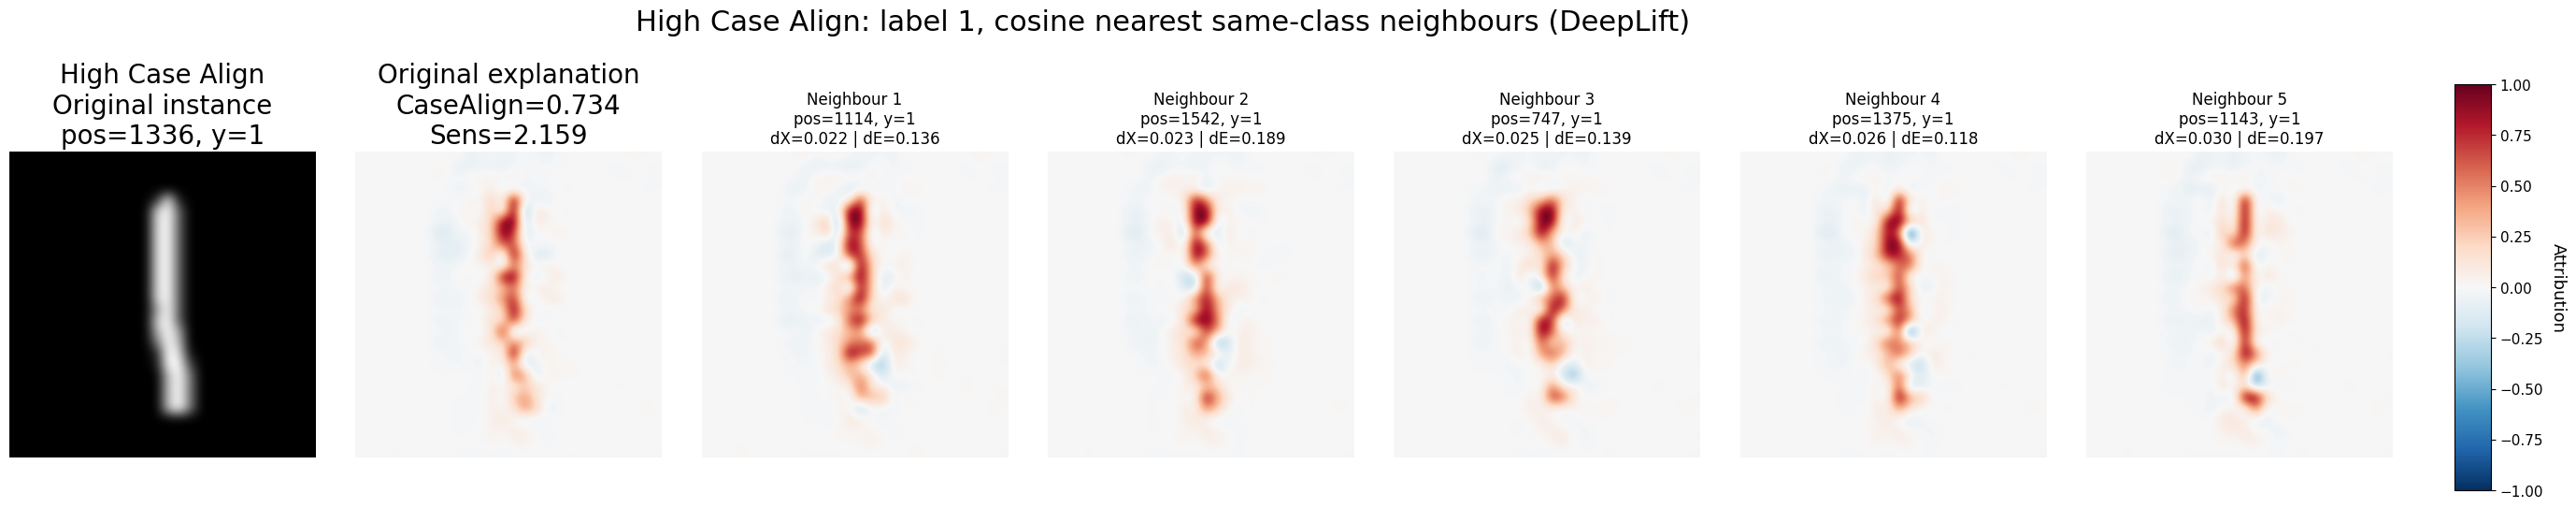

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_high_case_align_cosine_neighbours_overlay.png
Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_high_case_align_cosine_neighbours_overlay.pdf


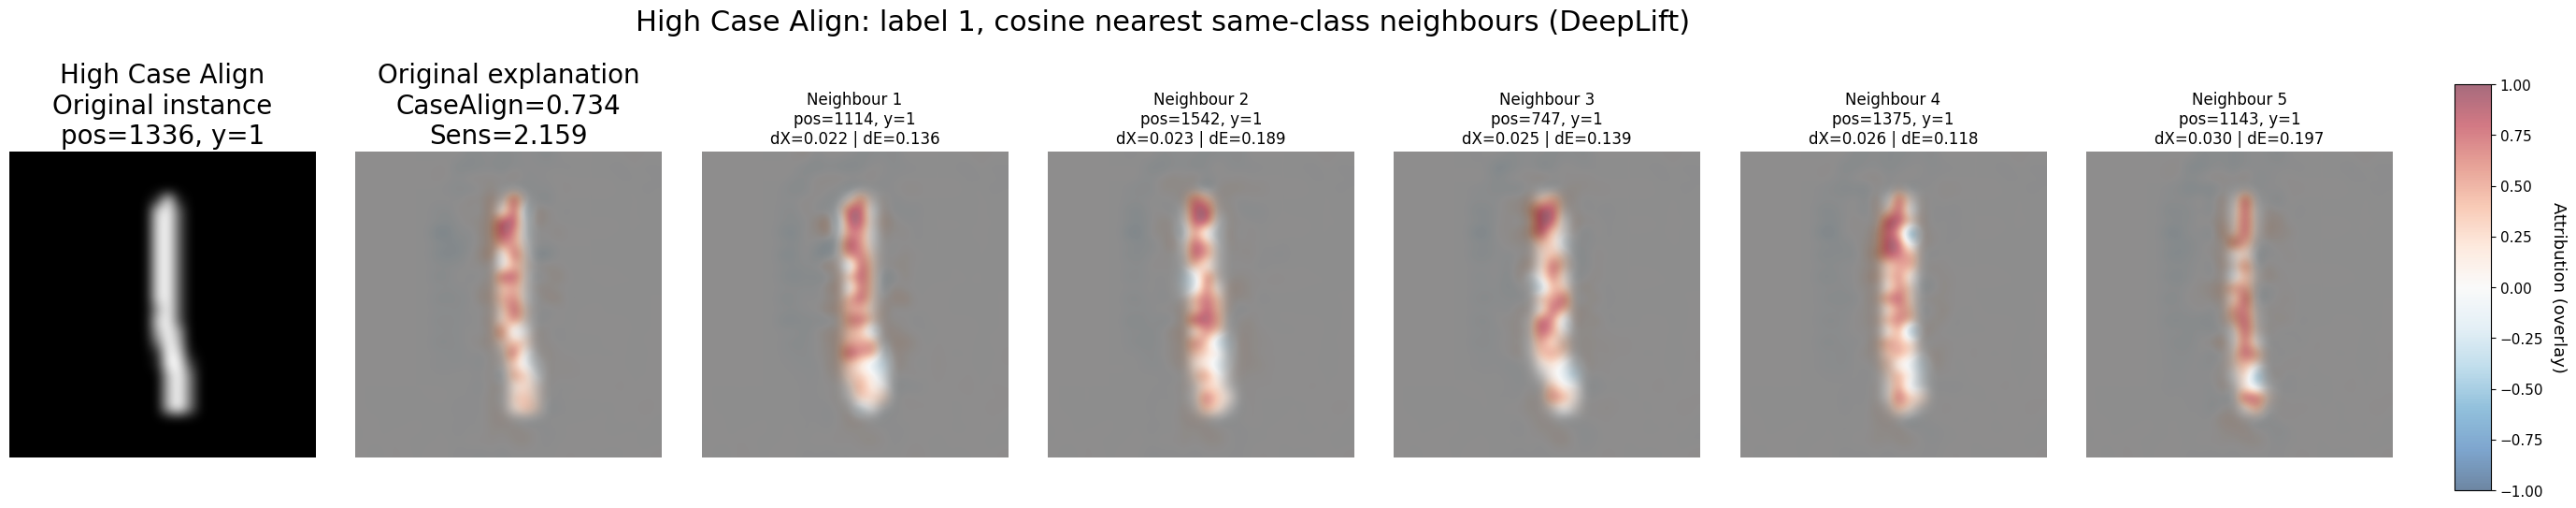

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_low_case_align_cosine_neighbours_attr_only.png
Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_low_case_align_cosine_neighbours_attr_only.pdf


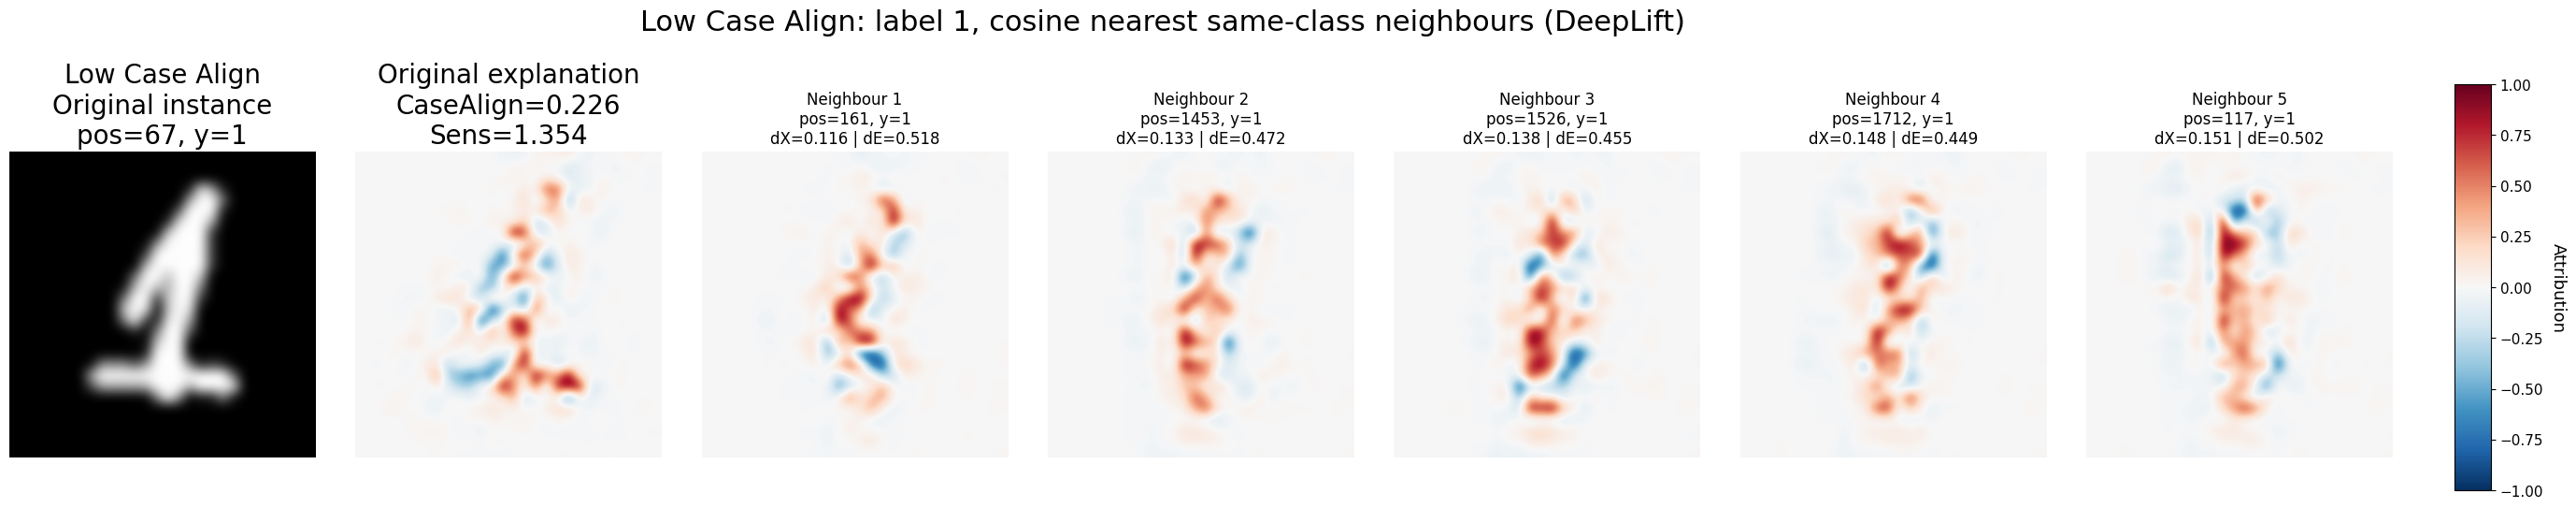

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_low_case_align_cosine_neighbours_overlay.png
Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_low_case_align_cosine_neighbours_overlay.pdf


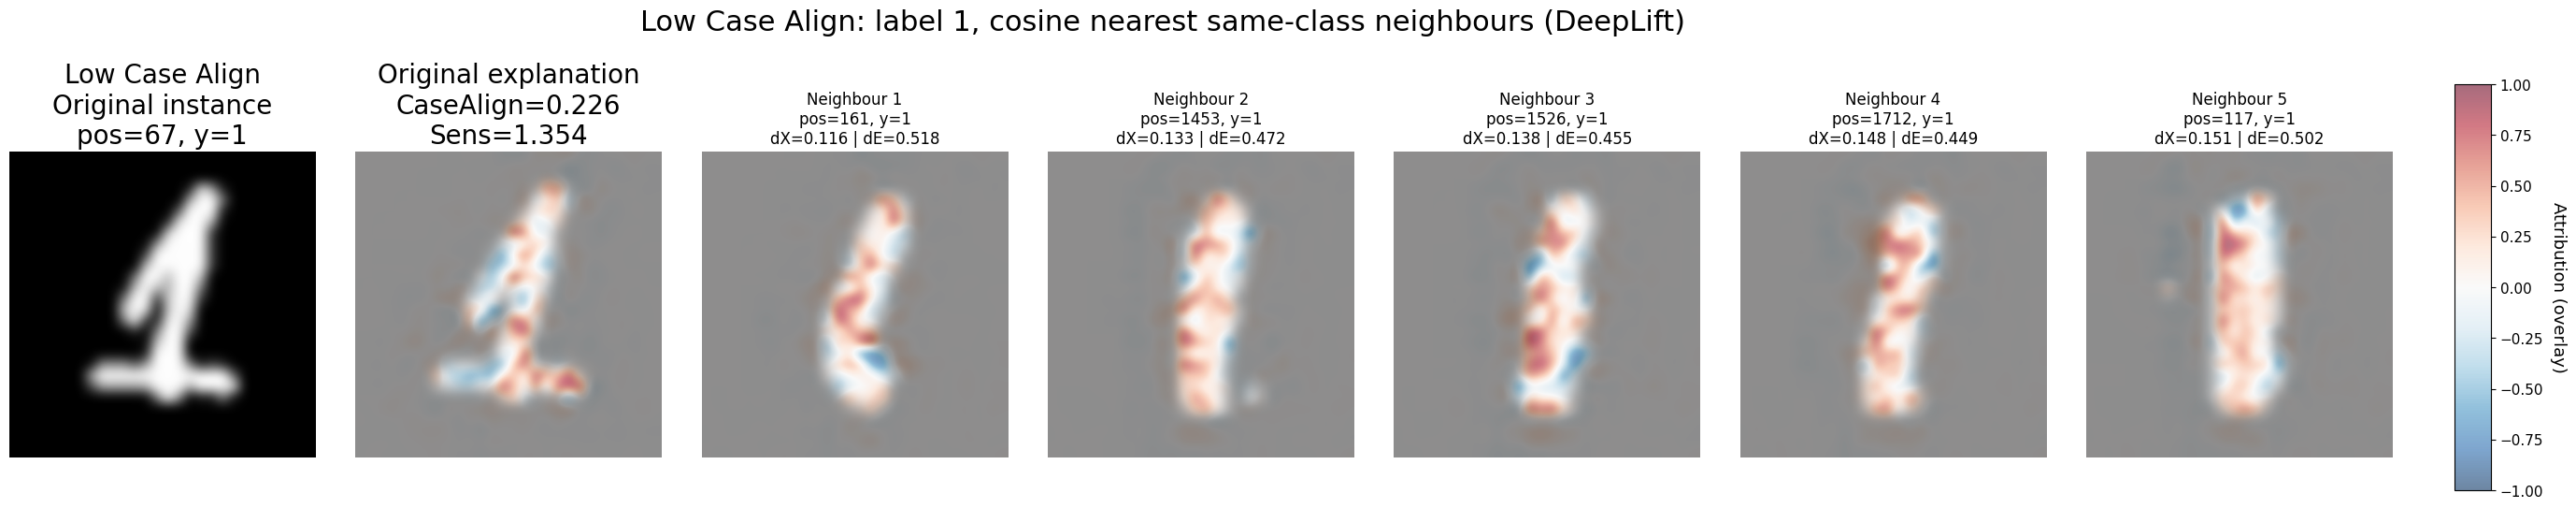

In [14]:
TITLE_FONTSIZE = 20
SUBTITLE_FONTSIZE = 12
SUPTITLE_FONTSIZE = 22
COLORBAR_LABEL_FONTSIZE = 13
COLORBAR_TICK_FONTSIZE = 11
DPI = 300

def plot_case_align_neighbours(panel_name: str, anchor_pos: int, *, overlay: bool = False):
    anchor_score = score_row(REFERENCE_METHOD, anchor_pos)
    neigh = neighbour_tables[panel_name.lower().split()[0]]
    n_cols = DISPLAY_K + 2

    fig, axes = plt.subplots(1, n_cols, figsize=(4.7 * n_cols, 6.2))
    fig.subplots_adjust(wspace=0.13, right=0.90, top=0.84, bottom=0.08)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    axes[0].imshow(images[anchor_pos, 0], cmap='gray', interpolation='bicubic')
    axes[0].set_title(
        f"{panel_name}\nOriginal instance\npos={anchor_pos}, y={int(labels[anchor_pos])}",
        fontsize=TITLE_FONTSIZE,
    )
    axes[0].axis('off')

    anchor_attr = normalise_attr(attributions[REFERENCE_METHOD][anchor_pos, 0])
    if overlay:
        axes[1].imshow(images[anchor_pos, 0], cmap='gray', interpolation='bicubic')
        im = axes[1].imshow(anchor_attr, cmap='RdBu_r', vmin=-1, vmax=1, alpha=EXPERIMENT_PARAMS['overlay_alpha'], interpolation='bicubic')
    else:
        im = axes[1].imshow(anchor_attr, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='bicubic')
    axes[1].set_title(
        f"Original explanation\n"
        f"CaseAlign={anchor_score['case_align_S_plus']:.3f}\n"
        f"Sens={anchor_score['captum_sensitivity']:.3f}",
        fontsize=TITLE_FONTSIZE,
    )
    axes[1].axis('off')

    for _, nb_row in neigh.iterrows():
        ax = axes[int(nb_row['rank']) + 1]
        nb_pos = int(nb_row['sample_position'])
        nb_attr = normalise_attr(attributions[REFERENCE_METHOD][nb_pos, 0])
        if overlay:
            ax.imshow(images[nb_pos, 0], cmap='gray', interpolation='bicubic')
            im = ax.imshow(nb_attr, cmap='RdBu_r', vmin=-1, vmax=1, alpha=EXPERIMENT_PARAMS['overlay_alpha'], interpolation='bicubic')
        else:
            im = ax.imshow(nb_attr, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='bicubic')
        ax.set_title(
            f"Neighbour {int(nb_row['rank'])}\npos={nb_pos}, y={int(nb_row['true_label'])}\n"
            f"dX={nb_row['problem_cosine_distance']:.3f} | dE={nb_row['solution_cosine_distance']:.3f}",
            fontsize=SUBTITLE_FONTSIZE,
        )
        ax.axis('off')

    cbar_ax = fig.add_axes([0.92, 0.14, 0.012, 0.70])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Attribution' + (' (overlay)' if overlay else ''), rotation=270, labelpad=18, fontsize=COLORBAR_LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE)

    style = 'overlay' if overlay else 'attr_only'
    fig.suptitle(
        f"{panel_name}: label {int(labels[anchor_pos])}, cosine nearest same-class neighbours ({METHOD_LABEL.get(REFERENCE_METHOD, REFERENCE_METHOD.upper())})",
        fontsize=SUPTITLE_FONTSIZE,
        y=0.97,
    )

    slug = panel_name.lower().replace(' ', '_')
    png_path = OUTPUT_DIR / f"mnist_label_{int(labels[anchor_pos])}_{slug}_cosine_neighbours_{style}.png"
    pdf_path = OUTPUT_DIR / f"mnist_label_{int(labels[anchor_pos])}_{slug}_cosine_neighbours_{style}.pdf"
    fig.savefig(png_path, dpi=DPI, bbox_inches='tight')
    fig.savefig(pdf_path, dpi=DPI, bbox_inches='tight')
    print(f'Saved: {png_path}')
    print(f'Saved: {pdf_path}')
    plt.show()

for panel_name, anchor_pos in [('High Case Align', pair_selection['high']), ('Low Case Align', pair_selection['low'])]:
    plot_case_align_neighbours(panel_name, anchor_pos, overlay=False)
    plot_case_align_neighbours(panel_name, anchor_pos, overlay=True)

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_compact_cosine_case_align_neighbours.png
Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_visualizations/nearest_neighbour_case_align/mnist_label_1_compact_cosine_case_align_neighbours.pdf


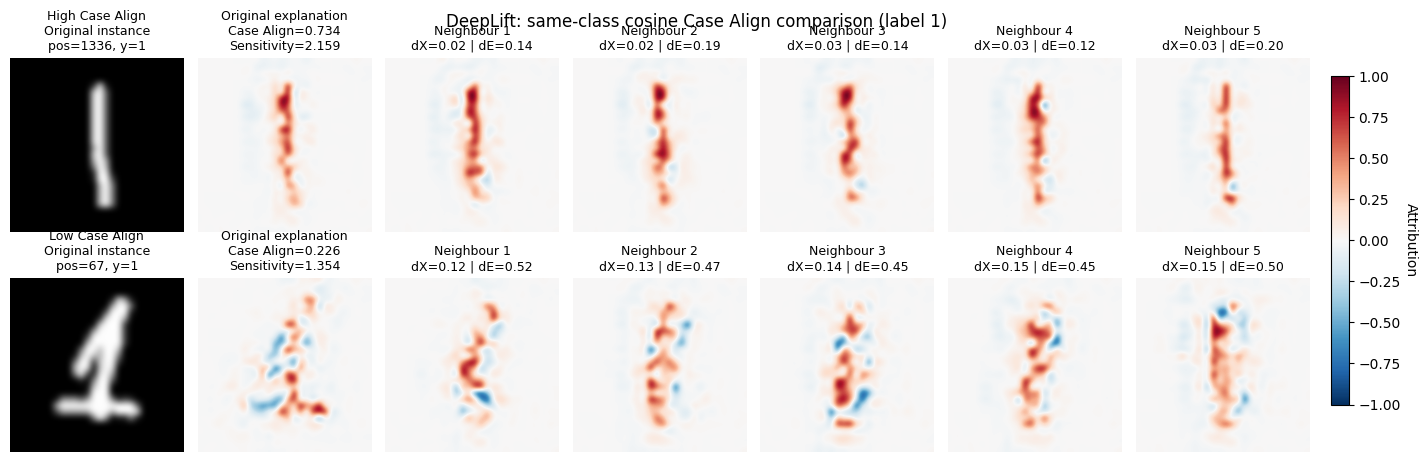

In [15]:
# Compact two-row figure for paper drafts.
fig, axes = plt.subplots(2, DISPLAY_K + 2, figsize=(14.6, 4.9))
fig.subplots_adjust(wspace=0.08, hspace=0.18, right=0.92, left=0.03, top=0.90, bottom=0.07)

im = None
for row_idx, (row_name, anchor_pos, table_key) in enumerate([
    ('High Case Align', pair_selection['high'], 'high'),
    ('Low Case Align', pair_selection['low'], 'low'),
]):
    anchor_score = score_row(REFERENCE_METHOD, anchor_pos)
    neigh = neighbour_tables[table_key]

    axes[row_idx, 0].imshow(images[anchor_pos, 0], cmap='gray', interpolation='bicubic')
    axes[row_idx, 0].set_title(
        f"{row_name}\nOriginal instance\npos={anchor_pos}, y={int(labels[anchor_pos])}",
        fontsize=9,
    )
    axes[row_idx, 0].axis('off')

    anchor_attr = normalise_attr(attributions[REFERENCE_METHOD][anchor_pos, 0])
    im = axes[row_idx, 1].imshow(anchor_attr, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='bicubic')
    axes[row_idx, 1].set_title(
        f"Original explanation\nCase Align={anchor_score['case_align_S_plus']:.3f}\nSensitivity={anchor_score['captum_sensitivity']:.3f}",
        fontsize=9,
    )
    axes[row_idx, 1].axis('off')

    for _, nb_row in neigh.iterrows():
        col = int(nb_row['rank']) + 1
        nb_pos = int(nb_row['sample_position'])
        nb_attr = normalise_attr(attributions[REFERENCE_METHOD][nb_pos, 0])
        im = axes[row_idx, col].imshow(nb_attr, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='bicubic')
        axes[row_idx, col].set_title(
            f"Neighbour {int(nb_row['rank'])}\ndX={nb_row['problem_cosine_distance']:.2f} | dE={nb_row['solution_cosine_distance']:.2f}",
            fontsize=9,
        )
        axes[row_idx, col].axis('off')

cbar_ax = fig.add_axes([0.935, 0.18, 0.012, 0.67])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Attribution', rotation=270, labelpad=12)

fig.suptitle(
    f"{METHOD_LABEL.get(REFERENCE_METHOD, REFERENCE_METHOD.upper())}: same-class cosine Case Align comparison (label {pair_selection['label']})",
    fontsize=12,
)
compact_png = OUTPUT_DIR / f"mnist_label_{pair_selection['label']}_compact_cosine_case_align_neighbours.png"
compact_pdf = OUTPUT_DIR / f"mnist_label_{pair_selection['label']}_compact_cosine_case_align_neighbours.pdf"
fig.savefig(compact_png, dpi=DPI, bbox_inches='tight')
fig.savefig(compact_pdf, dpi=DPI, bbox_inches='tight')
print(f'Saved: {compact_png}')
print(f'Saved: {compact_pdf}')
plt.show()